In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
import numpy as np
import pandas as pd
import pickle
import datetime
import random
import sys
import os
import re

pv_production_folder = '../charging_station_env/initializer/pv_production_data'
pv_production_data = os.path.join(pv_production_folder, 'data.csv')
df = pd.read_csv(pv_production_data)
df['time'] = pd.to_datetime(df['time'], format='%Y%m%d:%H%M')

sdg_folder = '../charging_station_env/initializer/synthetic_data_generator'

# PV Production Data

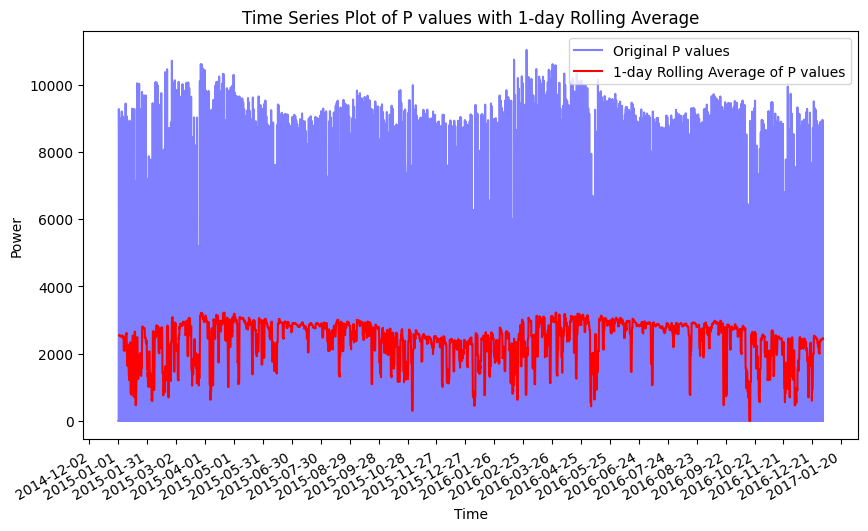

In [2]:
# From https://re.jrc.ec.europa.eu/pvg_tools/en/#MR

df['P_rolling_avg_1_day'] = df['P'].rolling(window=24).mean()

# Plotting the original and smoothed time series data
plt.figure(figsize=(10, 6))
plt.plot(df['time'], df['P'], color='blue', alpha=0.5, label='Original P values')
plt.plot(df['time'], df['P_rolling_avg_1_day'], color='red', label='1-day Rolling Average of P values')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=30))  # Set interval to every month
plt.gcf().autofmt_xdate()  # Improve the x-axis date formatting

# Adding title and labels
plt.title('Time Series Plot of P values with 1-day Rolling Average')
plt.xlabel('Time')
plt.ylabel('Power')
plt.legend()

# Display the plot
plt.show()

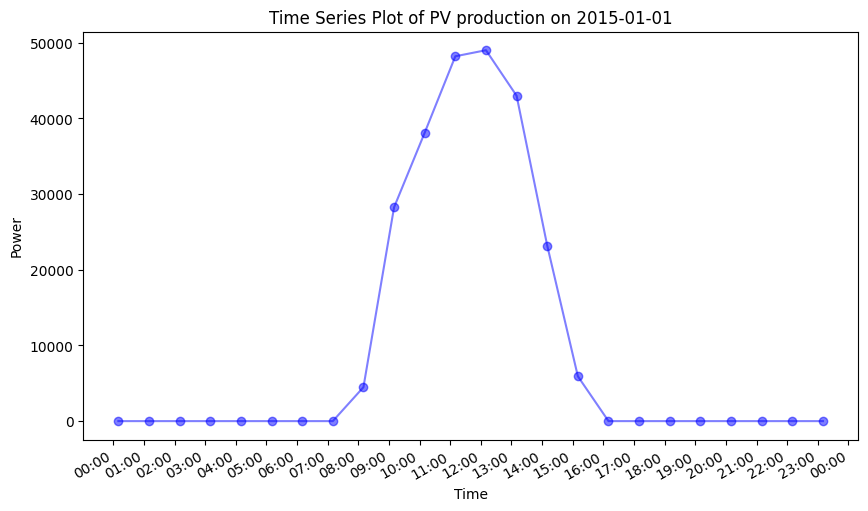

In [2]:
# Filtering the DataFrame for only one day (2015-01-01)
df_one_day = df[df['time'].dt.date == pd.to_datetime('2015-01-01').date()]

# Plotting the original and smoothed time series data for one day
plt.figure(figsize=(10, 6))
plt.plot(df_one_day['time'], df_one_day['P'], color='blue', marker='o', alpha=0.5)#, label='PV production')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Set x-axis formatter to show time only
plt.gca().xaxis.set_major_locator(mdates.HourLocator())  # Set interval to every hour
plt.gcf().autofmt_xdate()  # Improve the x-axis date formatting

# Adding title and labels
plt.title('Time Series Plot of PV production on 2015-01-01')
plt.xlabel('Time')
plt.ylabel('Power')
# plt.legend()

# Display the plot
plt.show()

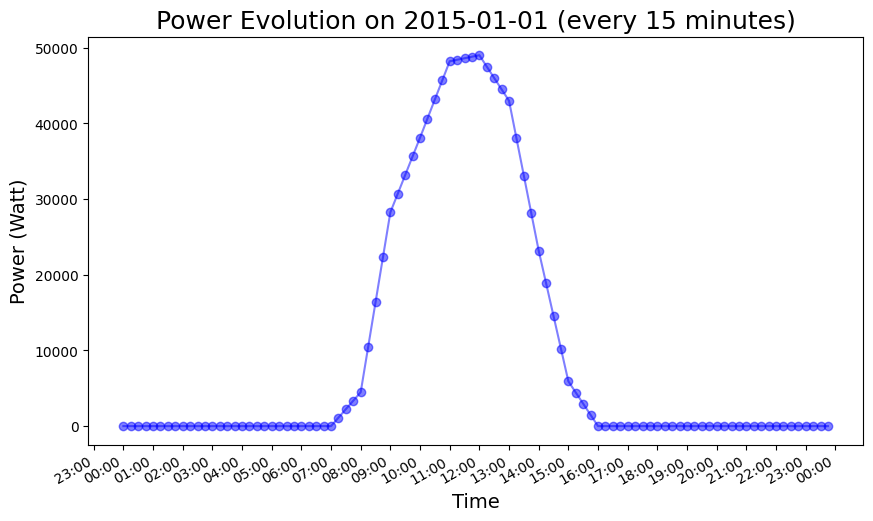

In [ ]:
# Resample the DataFrame to 15-minute intervals and interpolate the 'P' values
df_resampled = df.resample('15T', on='time').mean()
df_resampled['P'] = df_resampled['P'].interpolate()

# Filter the resampled DataFrame for only one day (2015-01-01)
df_one_day_15_min = df_resampled[df_resampled.index.date == pd.to_datetime('2015-01-01').date()]

# Plotting the power evolution for one day with 15-minute intervals
plt.figure(figsize=(10, 6))
plt.plot(df_one_day_15_min.index, df_one_day_15_min['P'], color='blue', marker='o', alpha=0.5)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Set x-axis formatter to show time only
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0]))  # Set interval to every hours
plt.gcf().autofmt_xdate()  # Improve the x-axis date formatting

# Adding title and labels
plt.title('Power Evolution on 2015-01-01 (every 15 minutes)', fontsize=18)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Power (Watt)', fontsize=14)

# Display the plot
plt.show()

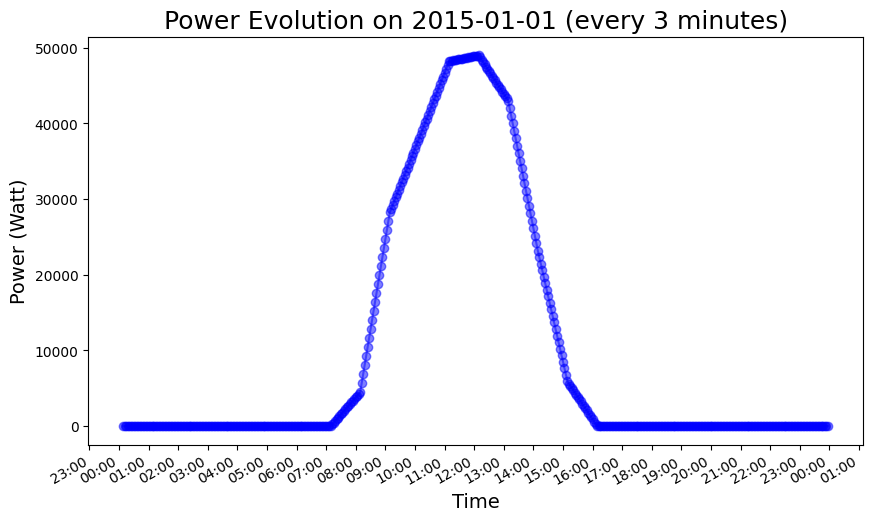

In [2]:
# Resample the DataFrame to 3-minute intervals and interpolate the 'P' values
df_resampled = df.resample('3T', on='time').mean()
df_resampled['P'] = df_resampled['P'].interpolate()

# Filter the resampled DataFrame for only one day (2015-01-01)
df_one_day_3_min = df_resampled[df_resampled.index.date == pd.to_datetime('2015-01-01').date()]

# Plotting the power evolution for one day with 3-minute intervals
plt.figure(figsize=(10, 6))
plt.plot(df_one_day_3_min.index, df_one_day_3_min['P'], color='blue', marker='o', alpha=0.5)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Set x-axis formatter to show time only
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0]))  # Set interval to every hours
plt.gcf().autofmt_xdate()  # Improve the x-axis date formatting

# Adding title and labels
plt.title('Power Evolution on 2015-01-01 (every 3 minutes)', fontsize=18)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Power (Watt)', fontsize=14)

# Display the plot
plt.show()

# Electricity Price Profiles

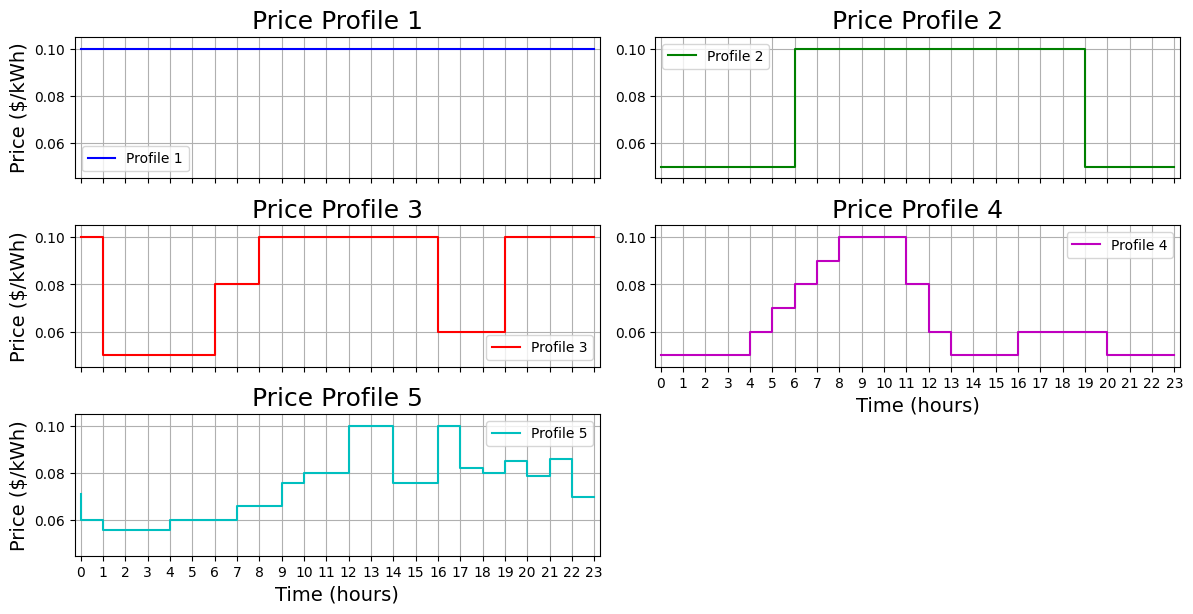

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Define the price profiles
p1 = np.array([0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.05, 0.05, 0.05, 0.05])
p2 = np.array([0.05, 0.05, 0.05, 0.05, 0.05, 0.06, 0.07, 0.08 ,0.09, 0.1, 0.1, 0.1, 0.08, 0.06, 0.05, 0.05, 0.05, 0.06, 0.06 ,0.06 ,0.06, 0.05, 0.05, 0.05])
p3 = np.array([0.071, 0.060, 0.056, 0.056, 0.056, 0.060, 0.060, 0.060, 0.066, 0.066, 0.076, 0.080, 0.080, 0.1, 0.1, 0.076, 0.076, 0.1, 0.082, 0.080, 0.085, 0.079, 0.086, 0.070])
p4 = np.array([0.1, 0.1, 0.05, 0.05, 0.05, 0.05, 0.05, 0.08, 0.08, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.06, 0.06, 0.06, 0.1, 0.1, 0.1, 0.1])
p5 = np.ones(24) * 0.1

# Create time axis for the plot
time_axis = np.arange(0, 24)

# Create subplots with 2 columns and 3 rows, sharing the x-axis across columns
fig, axs = plt.subplots(3, 2, figsize=(12, 6), sharex=True)

# Flatten the array of axes for easy iteration
axs = axs.flatten()

# Plot each price profile
axs[0].plot(time_axis, p5, label='Profile 1', color='b')
axs[1].step(time_axis, p1, where='pre', label='Profile 2', color='g')
axs[2].step(time_axis, p4, where='pre', label='Profile 3', color='r')
axs[3].step(time_axis, p2, where='pre', label='Profile 4', color='m')
axs[4].step(time_axis, p3, where='pre', label='Profile 5', color='c')

# Since we have only five profiles, we'll turn off the last subplot
axs[5].axis('off')

# Add titles, labels, and legends
for i, ax in enumerate(axs[:-1]):  # Skip the last subplot
    ax.set_title(f'Price Profile {i+1}', fontsize=18)
#     if i < len(axs)-3:
#         ax.label_outer()
    if i % 2 == 0:  # Only add y labels to the left column
        ax.set_ylabel('Price ($/kWh)', fontsize=14)
    ax.set_xticks(time_axis)
    ax.set_xticklabels(time_axis)
    ax.grid(True)
    ax.legend()
    
    ax.set_xlim([-.25, 23.25])  # Setting x-axis limits to reduce the blank space
    ax.set_ylim([min(min(p1), min(p2), min(p3), min(p4), min(p5)) - 0.005, 
                 max(max(p1), max(p2), max(p3), max(p4), max(p5)) + 0.005])

plt.tight_layout()
# Set the xlabel for the bottom plots since x-axis is shared
axs[3].set_xlabel('Time (hours)', fontsize=14)
axs[3].tick_params(labelbottom=True)
axs[4].set_xlabel('Time (hours)', fontsize=14)

plt.savefig('price_profiles.png', dpi=600, bbox_inches='tight')

# plt.tight_layout()
plt.show()

# Synthetic Data Generator

In [7]:
from charging_station_env.initializer.synthetic_data_generator.generate_sample import generate_sample
import charging_station_env.initializer.synthetic_data_generator.modeling as modeling
import charging_station_env.initializer.synthetic_data_generator.handles as handles
sys.modules['modeling'] = modeling
sys.modules['handles'] = handles


MODELS = {"ACpoisson_fit": "SDG Model (AC,poisson_fit)",
          "AVneg_bio_reg": "SDG Model (AC,neg_bio_reg)",
          "IATloess": "SDG Model (IAT,poly)",
          "IATmean": "SDG Model (IAT,mean)"}

model_name = MODELS['ACpoisson_fit']
file = os.path.join('../charging_station_env/initializer/synthetic_data_generator', model_name)
with open(file, 'rb') as f:
    x = pickle.load(f)
AM,MMc,MMe = x[0], x[1], x[2]

horizon_start = datetime.datetime.strptime('01/01/2015', '%d/%m/%Y')
horizon_end = horizon_start + datetime.timedelta(days=1)
list_df = []
for _ in range(364):
    try:
        list_df.append( generate_sample(AM=AM, MMc=MMc, MMe=MMe,
                                horizon_start=horizon_start, horizon_end=horizon_end, n=float('+inf')) )
        horizon_start = horizon_start + datetime.timedelta(days=1)
        horizon_end = horizon_start + datetime.timedelta(days=1)
    except:
        horizon_start = horizon_start + datetime.timedelta(days=1)
        horizon_end = horizon_start + datetime.timedelta(days=1)

df = pd.concat(list_df, ignore_index=True)
df

,Date,Arrival,Connected_time,Energy_required,AM_specs,MMc_specs,MMe_specs
0,2015-01-01,0.2,10.368431,14.215912,Arrival model {mod=poisson_fit variablity=True},Connected time model {mix=normal method=EM},Energy Required model {mix=normal method=EM}
1,2015-01-01,0.4,15.137398,9.024426,Arrival model {mod=poisson_fit variablity=True},Connected time model {mix=normal method=EM},Energy Required model {mix=normal method=EM}
2,2015-01-01,0.6,9.500238,12.752543,Arrival model {mod=poisson_fit variablity=True},Connected time model {mix=normal method=EM},Energy Required model {mix=normal method=EM}
3,2015-01-01,0.8,10.01782,8.079528,Arrival model {mod=poisson_fit variablity=True},Connected time model {mix=normal method=EM},Energy Required model {mix=normal method=EM}
4,2015-01-01,1.5,6.807203,9.193972,Arrival model {mod=poisson_fit variablity=True},Connected time model {mix=normal method=EM},Energy Required model {mix=normal method=EM}
...,...,...,...,...,...,...,...
362766,2015-11-02,23.545455,0.864036,13.620139,Arrival model {mod=poisson_fit variablity=True},Connected time model {mix=normal method=EM},Energy Required model {mix=normal method=EM}
362767,2015-11-02,23.636364,13.040877,9.710747,Arrival model {mod=poisson_fit variablity=True},Connected time model {mix=normal method=EM},Energy Required model {mix=normal method=EM}
362768,2015-11-02,23.727273,14.981112,4.14544,Arrival model {mod=poisson_fit variablity=True},Connected time model {mix=normal method=EM},Energy Required model {mix=normal method=EM}
362769,2015-11-02,23.818182,8.158997,6.213948,Arrival model {mod=poisson_fit variablity=True},Connected time model {mix=normal method=EM},Energy Required model {mix=normal method=EM}


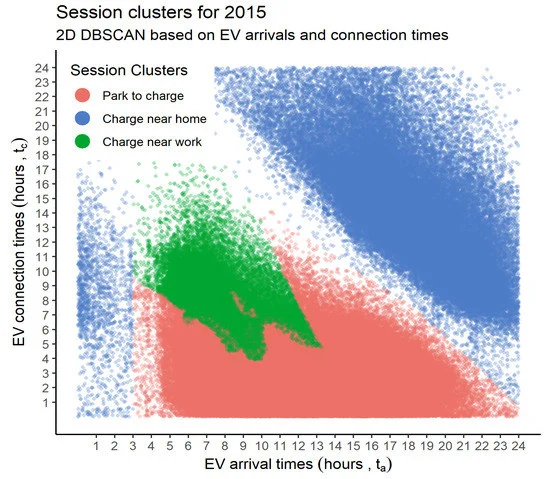

## Arrivals

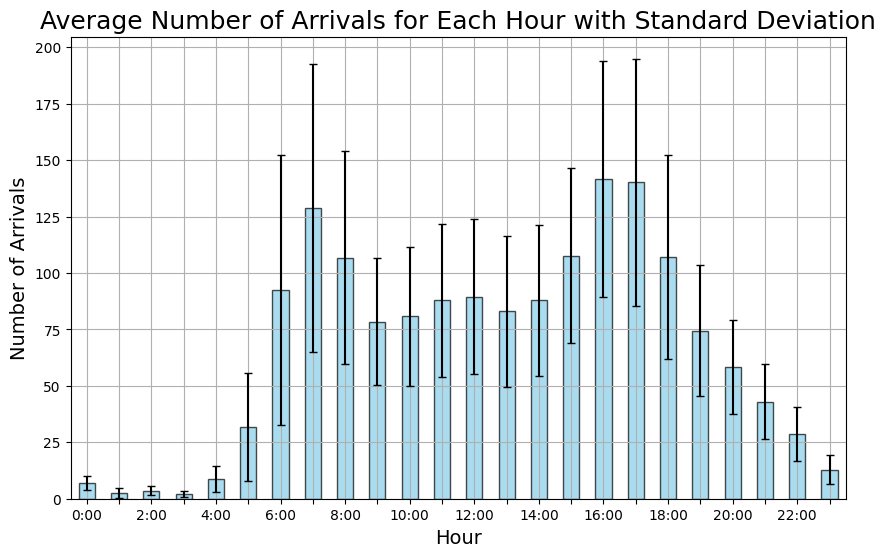

In [8]:
df_new = df.copy()
df_new['Hour'] = df_new['Arrival'].apply(np.round).astype(int) % 24
grouped = df_new.groupby(['Date', 'Hour']).size().unstack(fill_value=0)
grouped_reset = grouped.reset_index()
melted = pd.melt(grouped_reset, id_vars=['Date'], value_vars=grouped_reset.columns[1:],
                 var_name='Hour', value_name='Count')
melted['Date'] = pd.to_datetime(melted['Date'])
melted.sort_values(by=['Date', 'Hour'], inplace=True)
average_day = melted.groupby('Hour')['Count'].mean()
std_day = melted.groupby('Hour')['Count'].std()
plt.figure(figsize=(10, 6))
average_day.plot(kind='bar', yerr=std_day, capsize=3, color='skyblue', edgecolor='black', alpha=0.7)
plt.xticks(range(24), labels=[f'{hour}:00' for hour in range(24)], rotation=0)
plt.xlabel('Hour', fontsize=14)
plt.ylabel('Number of Arrivals', fontsize=14)
plt.title('Average Number of Arrivals for Each Hour with Standard Deviation', fontsize=18)
plt.grid(True)
plt.xticks(range(24), labels=[f'{hour}:00' if hour % 2 == 0 else '' for hour in range(24)], rotation=0)

plt.savefig('arrivals_dist.png', dpi=600, bbox_inches='tight')
plt.show()

## Parking Duration

### Initial Data

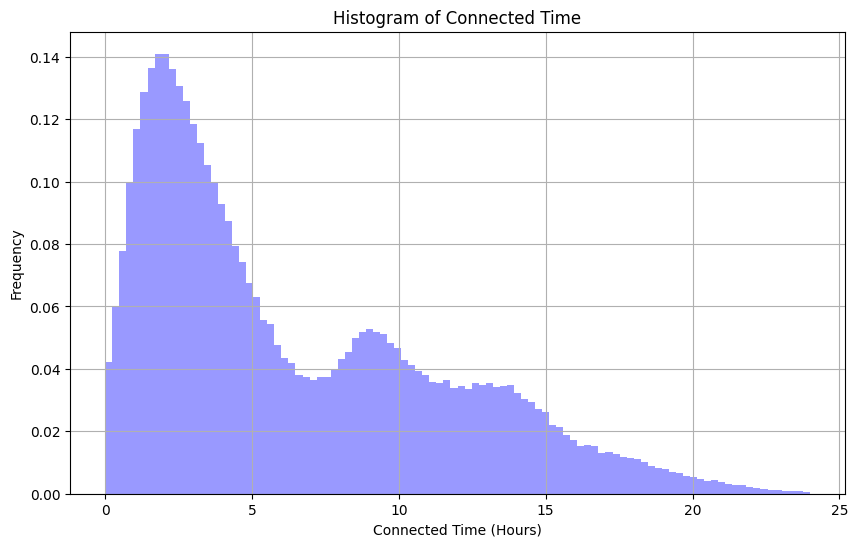

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(df['Connected_time'], density=True, bins=100, color='blue', alpha=0.4)
plt.title('Histogram of Connected Time')
plt.xlabel('Connected Time (Hours)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Modifications

Minimal parking duration required calculation:
$\frac{B \times (0.8 - SOC_j^0)}{P \times \tau} = dur^{min}_j$

Where:
- $B$ is the battery capacity
- $SOC_j^0$ is the inital SOC of the EV $j$
- $P$ is power delivered by a charger unit
- $\tau$ is the size of a timestep in hour (e.g. $\tau=0.25$ for 15min)

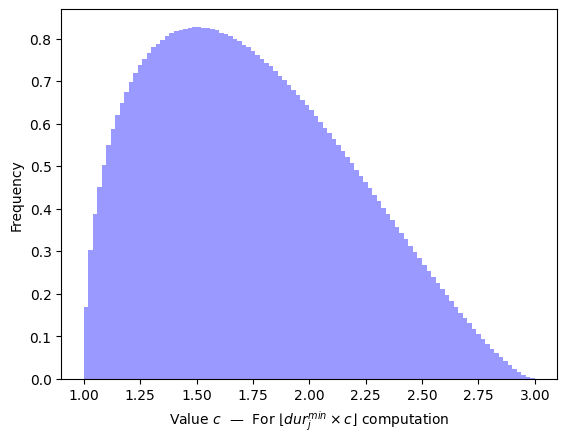

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

alpha_param, beta_param = 1.5, 2.5
size = int(1e8)
rvs = np.random.beta(alpha_param, beta_param, size)
coeff = 2
bias = 1
rvs = rvs * coeff + bias
plt.hist(rvs, bins=100, density=True, alpha=0.4, color='b')

plt.title('Histogram of the Beta Distribution')
plt.xlabel(r'Value $c$  —  For $\lfloor dur^{min}_j \times c \rfloor$ computation')
plt.ylabel('Frequency')
plt.show()

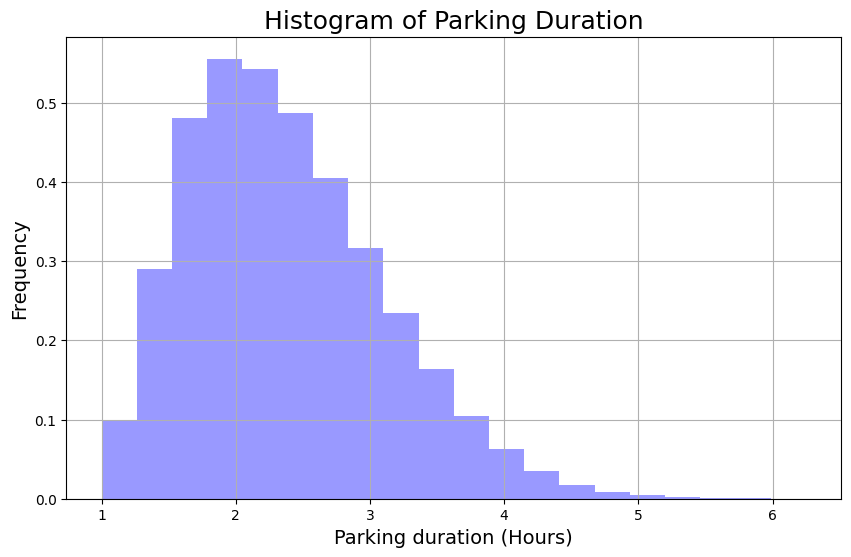

In [14]:
soc_min, soc_max = .1, .6
p = 11 * .91
B = 45
tau = 0.25
initial_soc_computed = soc_max - (df['Energy_required'] * (soc_max - soc_min))/((1 - soc_min) * B)
dur_min = (B * (.8 - initial_soc_computed)) / p * (1 / tau)

alpha_param, beta_param = 1.5, 2.5
coeff, bias = 2, 1
rvs = np.random.beta(alpha_param, beta_param, len(dur_min))
rvs = rvs * coeff + bias
durations = dur_min * rvs
durations = np.ceil(durations).astype(int) * tau

plt.figure(figsize=(10, 6))
plt.hist(durations, density=True, bins=20, color='blue', alpha=0.4)
plt.title('Histogram of Parking Duration', fontsize=18)
plt.xlabel('Parking duration (Hours)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True)

plt.savefig('parking_duration_dist.png', dpi=600, bbox_inches='tight')
plt.show()

## Initial SOC

### Initial Data

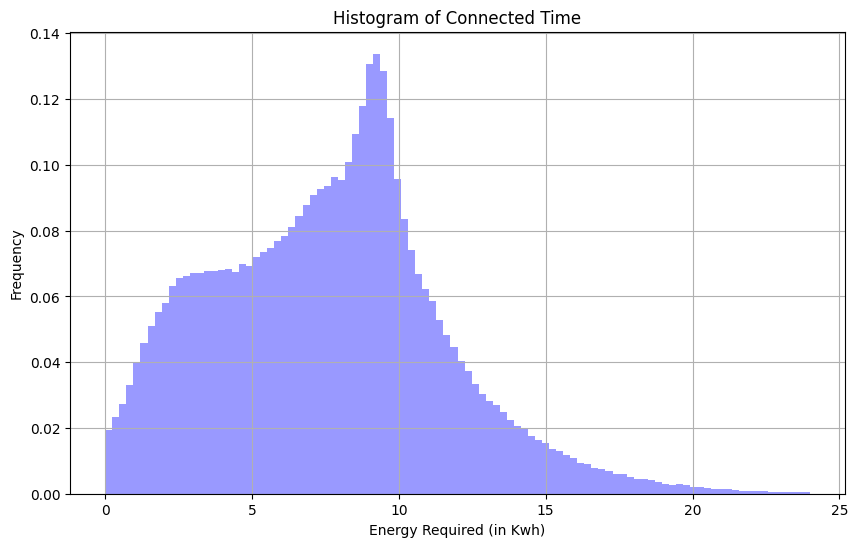

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(df['Energy_required'], density=True, bins=100, color='blue', alpha=0.4)
plt.title('Histogram of Connected Time')
plt.xlabel('Energy Required (in Kwh)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Modifications

SOC re-normalization calculation:
$SOC^{0}_j = SOC^{0}_{min} + \left(1 - \frac{e^{req}_j}{e^{req}_{max}}\right) \times (SOC^{0}_{max} - SOC^{0}_{min})$

Where:
- $B$ is the battery capacity
- $e^{req}_j$ is the energy required provided by the dataset
- $e^{req}_{min}$ and $e^{req}_{max}$ are the minimum and maximum energy required provided by the dataset
- $SOC^{0}_{min}$ and $SOC^{0}_{max}$ are 2 hyperparameters to set the min and max of the initial SOC at arrival

In [12]:
import random
import numpy as np
epsilon = 1e-4
soc_min, soc_max = .1, .6
e_req = np.array([random.random()*65 for _ in range(10)])
normalized_initial_soc = 1. - (e_req / e_req.max()) #(e_req / (e_req.max() - e_req.min()))
initial_soc_computed = soc_min + normalized_initial_soc * (soc_max - soc_min)

[e_req.min(), e_req.max()], [initial_soc_computed.min(), initial_soc_computed.max()]

([4.021372113488602, 63.289179063514496], [0.1, 0.5682301763666984])

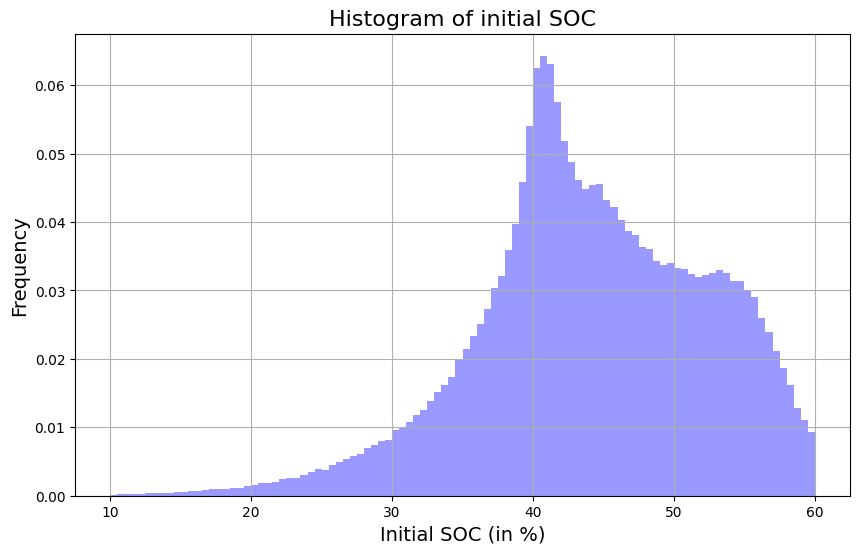

(10.001957286294164, 59.99987401902245)

In [15]:
soc_min, soc_max = .1, .6
B = 45
# initial_soc_computed = soc_max - (df['Energy_required'] * (soc_max - soc_min))/((1 - soc_min) * B)
epsilon = 1e-3
normalized_initial_soc = 1. - (df['Energy_required'] / (df['Energy_required'].max() - df['Energy_required'].min() + epsilon))
initial_soc_computed = soc_min + normalized_initial_soc * (soc_max - soc_min)
initial_soc_computed *= 100

plt.figure(figsize=(10, 6))
plt.hist(initial_soc_computed, density=True, bins=100, color='blue', alpha=0.4)
plt.title('Histogram of initial SOC', fontsize=16)
plt.xlabel('Initial SOC (in %)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True)

plt.savefig('soc_dist.png', dpi=600, bbox_inches='tight')
plt.show()

min(initial_soc_computed), max(initial_soc_computed)

# PPO comparison with and without masking on invalid actions

/tmp/ipykernel_2504542/2293547415.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0, i].set_yticklabels(axes[0, i].get_yticklabels(), fontsize=13)
/tmp/ipykernel_2504542/2293547415.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1, i].set_yticklabels(axes[1, i].get_yticklabels(), fontsize=13)


original_probabilities [0.25 0.25 0.25 0.25]
masked_probabilities [0.33333333 0.33333333 0.         0.33333333]
original_gradient [ 0.75 -0.25 -0.25 -0.25]
masked_gradient [ 0.66666667 -0.33333333 -0.         -0.33333333]


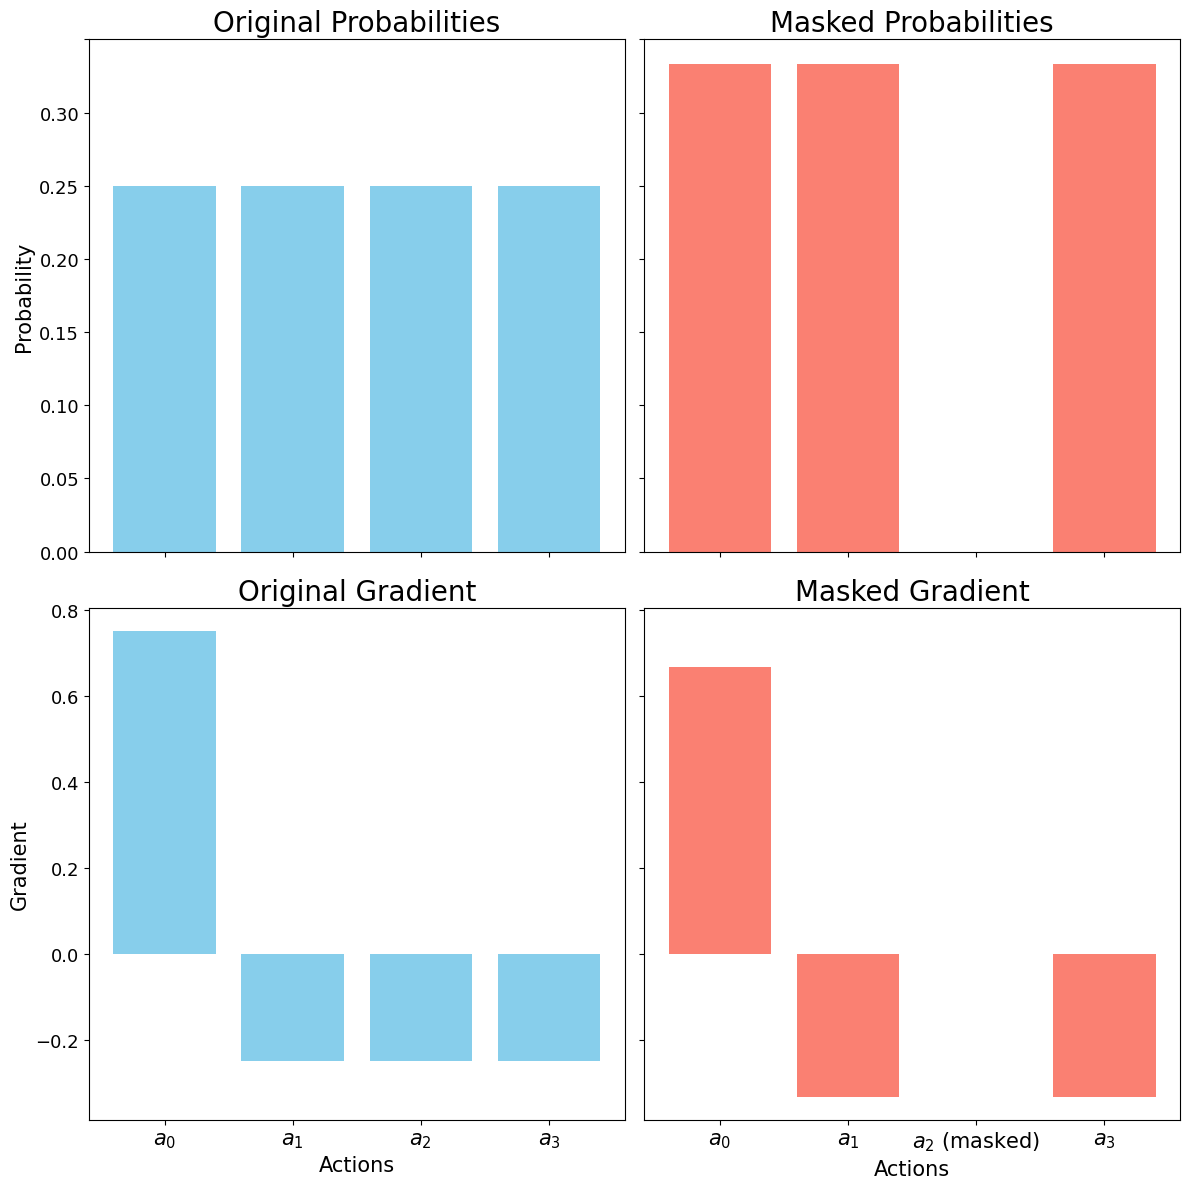

In [1]:
import matplotlib.pyplot as plt
import numpy as np


def softmax(logits):
    exp_logits = np.exp(logits - np.max(logits))
    return exp_logits / np.sum(exp_logits)

def gradient(probabilities):
    grad = np.zeros(probabilities.shape)
    grad[1:] = -probabilities[1:]
    grad[0] = - sum(grad[1:])
    return grad

original_logits = np.array([1.0, 1.0, 1.0, 1.0])
masked_logits = np.array([1.0, 1.0, -1e8, 1.0])

# Calculate probabilities and gradients
original_probabilities = softmax(original_logits)
masked_probabilities = softmax(masked_logits)
original_gradient = gradient(original_probabilities)
masked_gradient = gradient(masked_probabilities)

fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharey='row')

for i, (probs, grads, title) in enumerate([
    (original_probabilities, original_gradient, 'Original'),
    (masked_probabilities, masked_gradient, 'Masked')
]):
    # Probabilities plots
    axes[0, i].bar(range(4), probs, color=('skyblue' if title == 'Original' else 'salmon'))
    axes[0, i].set_title(f'{title} Probabilities', fontsize=20)
    if i == 0:
        axes[0, i].set_ylabel('Probability', fontsize=15)
        axes[0, i].set_yticklabels(axes[0, i].get_yticklabels(), fontsize=13)
    axes[0, i].set_xticks(range(4))
    axes[0, i].set_xticklabels(['', '', '', ''])

    # Gradient plots
    axes[1, i].bar(range(4), grads, color=('skyblue' if title == 'Original' else 'salmon'))
    axes[1, i].set_title(f'{title} Gradient', fontsize=20)
    axes[1, i].set_xlabel('Actions', fontsize=15)
    if i == 0:
        axes[1, i].set_ylabel('Gradient', fontsize=15)
        axes[1, i].set_yticklabels(axes[1, i].get_yticklabels(), fontsize=13)
    axes[1, i].set_xticks(range(4))
    axes[1, i].set_xticklabels([r'$a_0$', r'$a_1$', (r'$a_2$' if title == 'Original' else '$a_2$ (masked)'), '$a_3$'], fontsize=15)

print('original_probabilities', original_probabilities)
print('masked_probabilities', masked_probabilities)
print('original_gradient', original_gradient)
print('masked_gradient', masked_gradient)

plt.tight_layout()
# plt.savefig('ex_mppo.png', dpi=600, bbox_inches='tight')
plt.show()